# Préparation du df

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv(filepath_or_buffer = '../data/GLB.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)
# df = pd.read_csv(filepath_or_buffer = '../data/owid-co2-data.csv', sep = ',', header = 0, low_memory=False)

In [2]:
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-.18,-.18,***,***,-0.12,-0.17,-0.21
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.15,-0.22,-0.19,-.07,-.09,-.10,-.18,0.04,-0.08,-0.19
2,1882,0.16,0.14,0.04,-0.17,-0.15,-0.23,-0.17,-0.07,-0.14,-0.24,-0.17,-.36,-.11,-.09,.07,-0.09,-0.16,-0.18
3,1883,-0.29,-0.37,-0.13,-0.18,-0.17,-0.08,-0.07,-0.14,-0.21,-0.11,-0.23,-.11,-.17,-.20,-.34,-0.16,-0.09,-0.19
4,1884,-0.13,-0.07,-0.36,-0.40,-0.34,-0.36,-0.30,-0.27,-0.27,-0.25,-0.34,-.31,-.28,-.27,-.11,-0.37,-0.31,-0.29


In [3]:
df.sort_values(by=['Year'], ascending=False).head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
145,2025,1.37,1.25,1.36,1.23,1.07,1.05,1.02,1.15,1.24,1.19,1.22,***,***,1.20,1.30,1.22,1.07,1.22
144,2024,1.25,1.44,1.39,1.31,1.14,1.20,1.20,1.29,1.24,1.32,1.29,1.27,1.28,1.29,1.35,1.28,1.23,1.28
143,2023,0.87,0.97,1.23,0.99,0.94,1.08,1.19,1.19,1.48,1.34,1.42,1.37,1.17,1.12,.88,1.05,1.15,1.41
142,2022,0.91,0.89,1.04,0.83,0.84,0.92,0.94,0.95,0.89,0.97,0.73,.80,.89,.90,.89,0.90,0.94,0.86
141,2021,0.81,0.64,0.89,0.76,0.79,0.84,0.92,0.81,0.92,0.98,0.92,.87,.85,.84,.75,0.81,0.86,0.94


In [4]:
df.describe()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,MAM,JJA,SON
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,1952.500000,0.076233,0.085068,0.102671,0.076027,0.063767,0.051849,0.075822,0.075685,0.081301,0.106027,0.098836,0.080822,0.068082,0.095548
std,42.290661,0.446382,0.450972,0.457660,0.419034,0.395672,0.395746,0.378275,0.395652,0.398536,0.402568,0.411772,0.419312,0.386299,0.399208
min,1880.000000,-0.810000,-0.640000,-0.640000,-0.600000,-0.560000,-0.520000,-0.510000,-0.550000,-0.580000,-0.580000,-0.580000,-0.580000,-0.500000,-0.520000
25%,1916.250000,-0.250000,-0.240000,-0.227500,-0.250000,-0.240000,-0.250000,-0.190000,-0.217500,-0.197500,-0.197500,-0.177500,-0.250000,-0.217500,-0.187500
50%,1952.500000,-0.010000,-0.035000,0.015000,-0.015000,-0.035000,-0.050000,-0.030000,-0.040000,-0.055000,0.010000,0.020000,-0.015000,-0.040000,-0.010000
75%,1988.750000,0.320000,0.397500,0.342500,0.297500,0.280000,0.265000,0.290000,0.297500,0.272500,0.260000,0.287500,0.310000,0.310000,0.280000
max,2025.000000,1.370000,1.440000,1.390000,1.310000,1.140000,1.200000,1.200000,1.290000,1.480000,1.340000,1.420000,1.280000,1.230000,1.410000


In [5]:
# Affichage nb lignes et colonnes
df.shape

(146, 19)

In [6]:
# df['Col1'].unique()

In [7]:
# Affichage des types de chaque colonne
df.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun     float64
Jul     float64
Aug     float64
Sep     float64
Oct     float64
Nov     float64
Dec      object
J-D      object
D-N      object
DJF      object
MAM     float64
JJA     float64
SON     float64
dtype: object

# Nettoyage des données

In [8]:
# Calcul du nombre de doublons
df.duplicated().sum()

np.int64(0)

In [9]:
df['Dec'] = df['Dec'].fillna(0)
# etc.
# Nombre de valeurs uniques dans Col1 : ..

print('Dec', df['Dec'].isna().sum(axis = 0))

Dec 0


In [10]:
# Remplacement des données type string par des valeurs nulles et modification du type des colonnes par float
# Dec	
# J-D	
# D-N	
# DJF
df['Dec'] = df['Dec'].replace(to_replace = "***", value = None)
df['Dec'] = df['Dec'].astype(float)
df['J-D'] = df['J-D'].replace(to_replace = "***", value = None)
df['J-D'] = df['J-D'].astype(float)
df['D-N'] = df['D-N'].replace(to_replace = "***", value = None)
df['D-N'] = df['D-N'].astype(float)
df['DJF'] = df['DJF'].replace(to_replace = "***", value = None)
df['DJF'] = df['DJF'].astype(float)

# Affichage du df

In [11]:
# Affichage du df selon ordre ascendant ou descendant d'une colonne
df.sort_values(by=['Year'], ascending=True).head(60
)

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,NaN,NaN,-0.12,-0.17,-0.21
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.15,-0.22,-0.19,-0.07,-0.09,-0.10,-0.18,0.04,-0.08,-0.19
2,1882,0.16,0.14,0.04,-0.17,-0.15,-0.23,-0.17,-0.07,-0.14,-0.24,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.18
3,1883,-0.29,-0.37,-0.13,-0.18,-0.17,-0.08,-0.07,-0.14,-0.21,-0.11,-0.23,-0.11,-0.17,-0.20,-0.34,-0.16,-0.09,-0.19
4,1884,-0.13,-0.07,-0.36,-0.40,-0.34,-0.36,-0.30,-0.27,-0.27,-0.25,-0.34,-0.31,-0.28,-0.27,-0.11,-0.37,-0.31,-0.29
5,1885,-0.59,-0.34,-0.27,-0.42,-0.46,-0.44,-0.34,-0.32,-0.29,-0.24,-0.24,-0.11,-0.34,-0.35,-0.41,-0.38,-0.37,-0.25
6,1886,-0.44,-0.51,-0.43,-0.28,-0.25,-0.35,-0.19,-0.31,-0.24,-0.28,-0.28,-0.25,-0.32,-0.31,-0.35,-0.32,-0.28,-0.27
7,1887,-0.73,-0.57,-0.36,-0.35,-0.31,-0.25,-0.26,-0.36,-0.26,-0.36,-0.26,-0.34,-0.37,-0.36,-0.52,-0.34,-0.29,-0.29
8,1888,-0.35,-0.36,-0.42,-0.21,-0.22,-0.17,-0.11,-0.16,-0.12,0.01,0.02,-0.05,-0.18,-0.20,-0.35,-0.28,-0.15,-0.03
9,1889,-0.10,0.16,0.05,0.09,-0.01,-0.10,-0.07,-0.20,-0.24,-0.26,-0.34,-0.29,-0.11,-0.09,0.01,0.04,-0.13,-0.28


In [12]:
df.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun     float64
Jul     float64
Aug     float64
Sep     float64
Oct     float64
Nov     float64
Dec     float64
J-D     float64
D-N     float64
DJF     float64
MAM     float64
JJA     float64
SON     float64
dtype: object

<Axes: ylabel='J-D'>

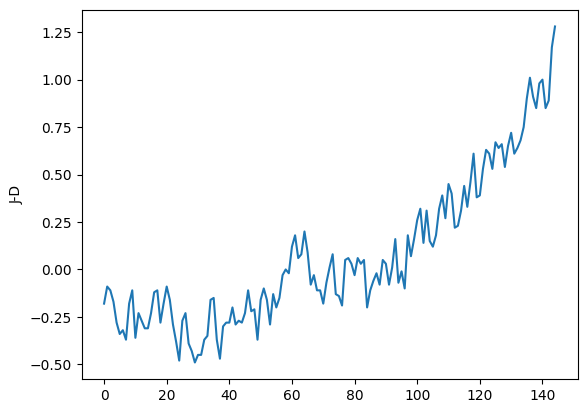

In [13]:
sns.lineplot(data=df['J-D'])

<Axes: ylabel='JJA'>

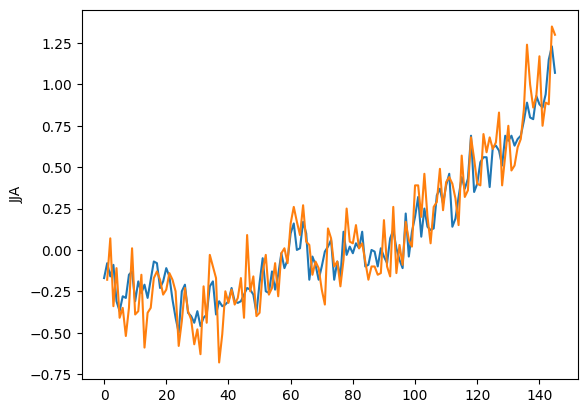

In [14]:
sns.lineplot(data=df['JJA'])
sns.lineplot(data=df['DJF'])

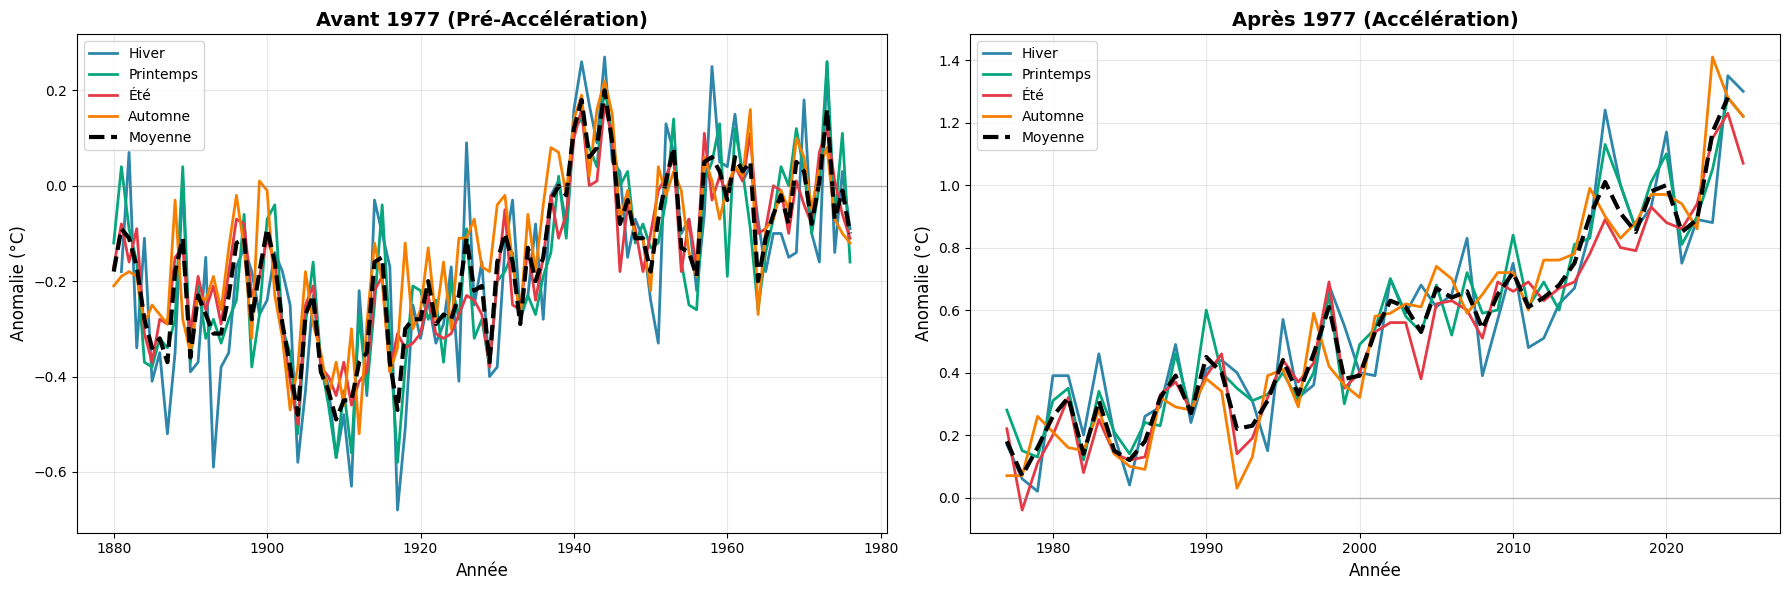

In [15]:
#COMPARAISON AVANT/APRÈS 1977 

#Séparer les données en deux périodes
df_avant = df[df['Year'] < 1977]   # Années avant 1977
df_apres = df[df['Year'] >= 1977]  # Années à partir de 1977

#deux graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#Graphique de gauche avant 1977
ax1 = axes[0]

#4 saisons + moyenne
ax1.plot(df_avant['Year'], df_avant['DJF'], label='Hiver', linewidth=2, color='#2E86AB')
ax1.plot(df_avant['Year'], df_avant['MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax1.plot(df_avant['Year'], df_avant['JJA'], label='Été', linewidth=2, color='#E63946')
ax1.plot(df_avant['Year'], df_avant['SON'], label='Automne', linewidth=2, color='#F77F00')
ax1.plot(df_avant['Year'], df_avant['J-D'], label='Moyenne', linewidth=3, color='black', linestyle='--')

# ligne à 0 pour référence
ax1.axhline(0, color='gray', linewidth=1, alpha=0.5)

#Titres et labels
ax1.set_title('Avant 1977 (Pré-Accélération)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Anomalie (°C)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

#Graphique de droite après 1977
ax2 = axes[1]

#4 saisons + moyenne
ax2.plot(df_apres['Year'], df_apres['DJF'], label='Hiver', linewidth=2, color='#2E86AB')
ax2.plot(df_apres['Year'], df_apres['MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax2.plot(df_apres['Year'], df_apres['JJA'], label='Été', linewidth=2, color='#E63946')
ax2.plot(df_apres['Year'], df_apres['SON'], label='Automne', linewidth=2, color='#F77F00')
ax2.plot(df_apres['Year'], df_apres['J-D'], label='Moyenne', linewidth=3, color='black', linestyle='--')

#ligne à 0 pour référence
ax2.axhline(0, color='gray', linewidth=1, alpha=0.5)

#Titres et labels
ax2.set_title('Après 1977 (Accélération)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Anomalie (°C)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('comparaison_avant_apres_1977.png', dpi=300, bbox_inches='tight')
plt.show()






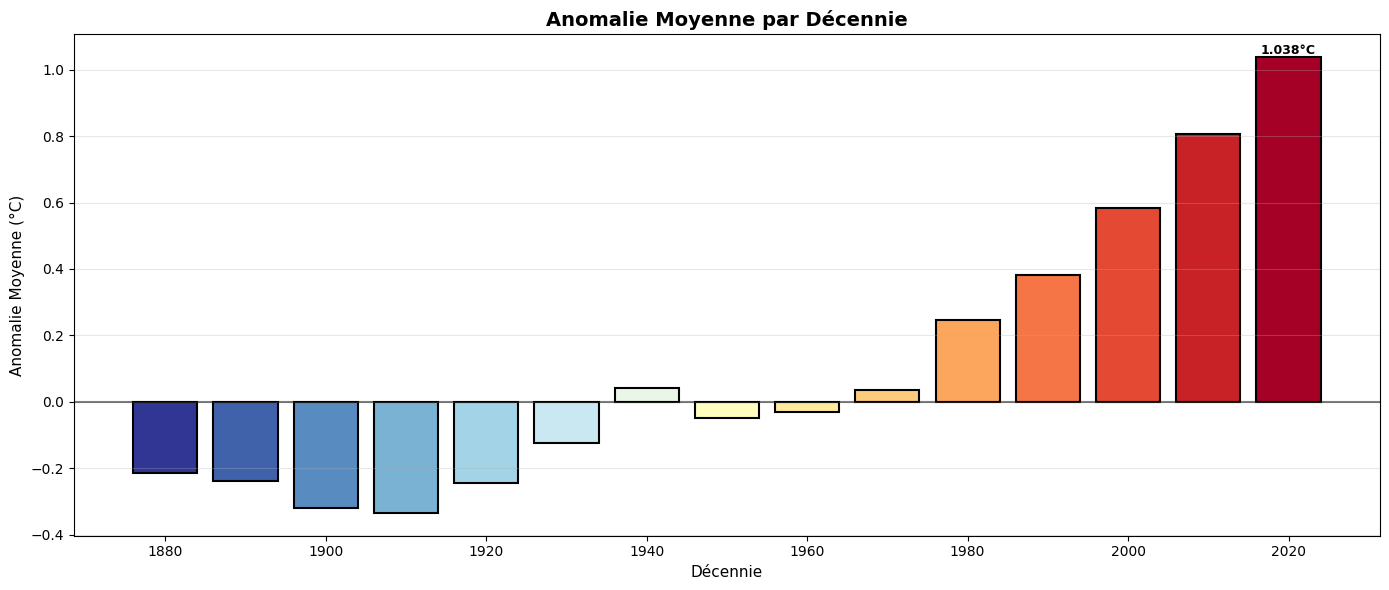

In [16]:
#Anomalie Moyenne par Décennie

#colonne "Décennie" 
df['Decade'] = (df['Year'] // 10) * 10

#Calcule de la moyenne par décennie
decade_means = df.groupby('Decade')['J-D'].mean()


fig, ax = plt.subplots(figsize=(14, 6))

#graphique en barres
decades = decade_means.index  # Les années (1880, 1890, ...)
values = decade_means.values  # Les anomalies moyennes

#Dégradé de couleurs (bleu froid → rouge chaud)
n_decades = len(decades)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, n_decades))

# Dessiner les barres
bars = ax.bar(decades, values, width=8, color=colors, 
edgecolor='black', linewidth=1.5)

#valeurs au-dessus des barres
for bar in bars:
 height = bar.get_height()
ax.text(bar.get_x() + bar.get_width()/2, height,
f'{height:.3f}°C', 
ha='center', va='bottom', fontsize=9, fontweight='bold')

#une ligne horizontale à 0
ax.axhline(0, color='black', linewidth=1.5, alpha=0.5)

#Titres et labels
ax.set_title('Anomalie Moyenne par Décennie', fontsize=14, fontweight='bold')
ax.set_xlabel('Décennie', fontsize=11)
ax.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig('anomalie_par_decennie.png', dpi=300, bbox_inches='tight')
plt.show()


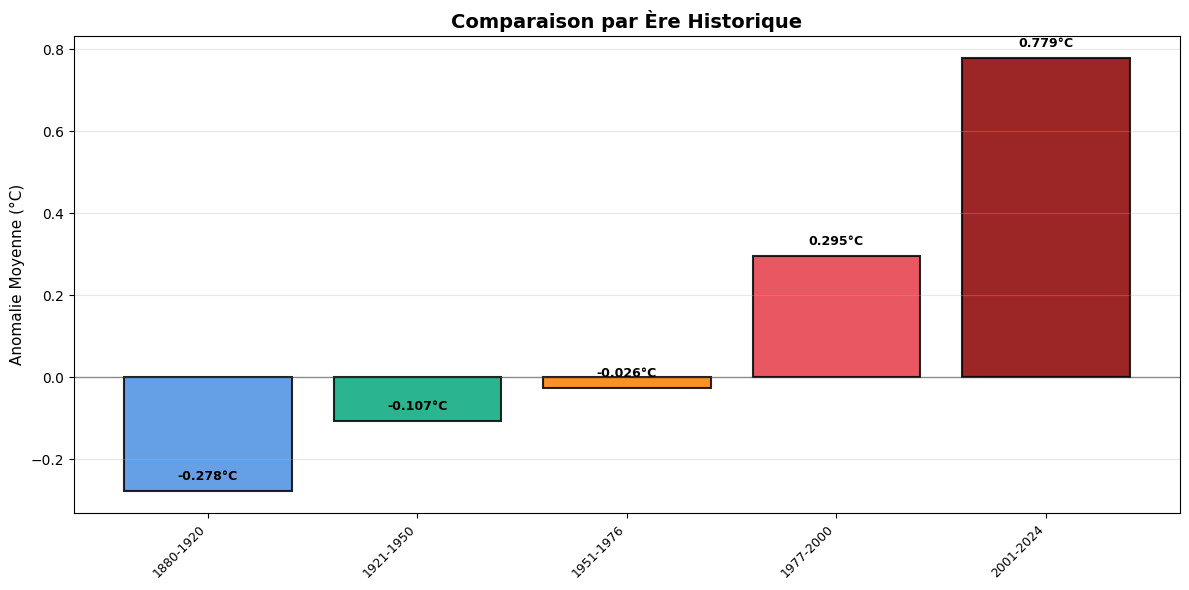

In [17]:
#Comparaison par période historique

#périodes à comparer
periodes = [
    ('1880-1920', 1880, 1920, '#4A90E2'),
    ('1921-1950', 1921, 1950, '#06A77D'),
    ('1951-1976', 1951, 1976, '#F77F00'),
    ('1977-2000', 1977, 2000, '#E63946'),
    ('2001-2024', 2001, 2024, '#8B0000')
]

#Calcule de la moyenne pour chaque période
labels = []       # Noms des périodes
moyennes = []     # Anomalies moyennes
couleurs = []     # Couleurs

for nom, debut, fin, couleur in periodes:
    #>Filtrer les données pour cette période
    donnees_periode = df[(df['Year'] >= debut) & (df['Year'] <= fin)]['J-D']
    
    #>Calculer la moyenne
    moyenne = donnees_periode.mean()
    
    #>Stocker les résultats
    labels.append(nom)
    moyennes.append(moyenne)
    couleurs.append(couleur)

# graphique
fig, ax = plt.subplots(figsize=(12, 6))

positions = range(len(labels))  # 0, 1, 2, 3, 4
bars = ax.bar(positions, moyennes, color=couleurs, 
              edgecolor='black', linewidth=1.5, alpha=0.85)

#Ajouter les valeurs au-dessus des barres
for i, (bar, valeur) in enumerate(zip(bars, moyennes)):
    hauteur = bar.get_height()
    ax.text(i, hauteur + 0.02, f'{valeur:.3f}°C',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

#Ajouter une ligne à 0
ax.axhline(0, color='black', linewidth=1, alpha=0.4)

#Personnaliser les axes
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
ax.set_title('Comparaison par Ère Historique', fontsize=14, fontweight='bold')
ax.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig('comparaison_periodes.png', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
from scipy.stats import linregress

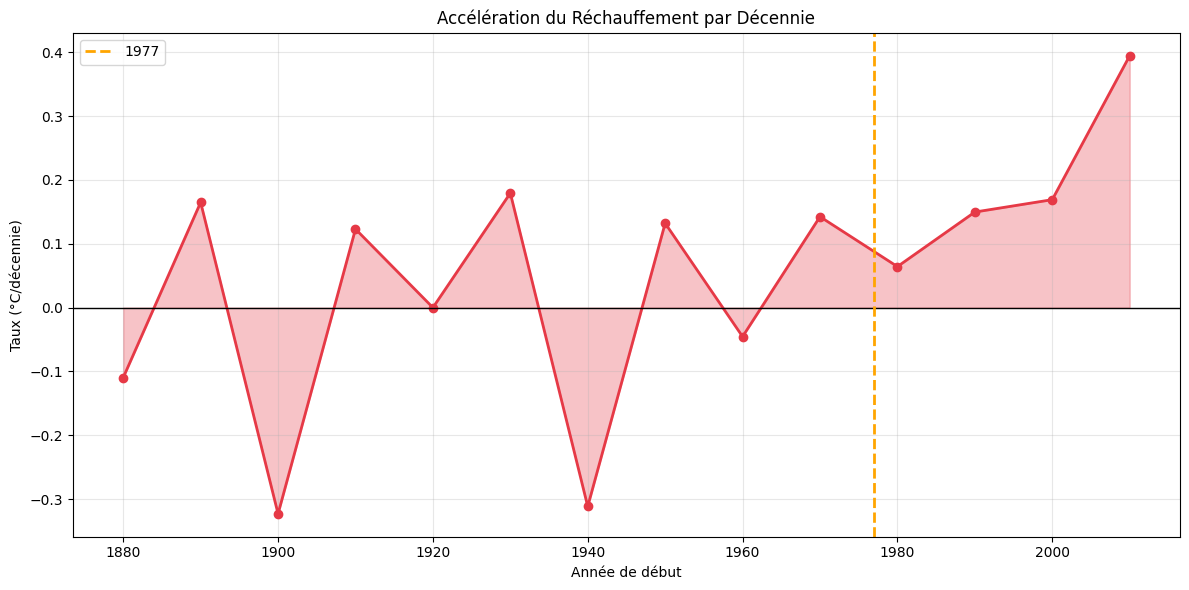

In [19]:
# Accélération du récchauffement

# 1. Calculer le taux de réchauffement pour chaque décennie
periodes = []  # Années de début (1880, 1890, 1900, ...)
taux = []      # Taux de réchauffement (°C par décennie)

for annee_debut in range(1880, 2015, 10):
    # Prendre 10 ans de données
    annee_fin = annee_debut + 10
    donnees = df[(df['Year'] >= annee_debut) & (df['Year'] < annee_fin)]
    
    # Calculer la tendance si on a assez de données
    if len(donnees) >= 5:
        slope, _, _, _, _ = linregress(donnees['Year'], donnees['J-D'])
        periodes.append(annee_debut)
        taux.append(slope * 10)  # Convertir en °C/décennie

#Créer le graphique
fig, ax = plt.subplots(figsize=(12, 6))

#Tracer la courbe
ax.plot(periodes, taux, marker='o', linewidth=2, markersize=6, color='#E63946')

#Ajouter des lignes de référence
ax.axhline(0, color='black', linewidth=1)           # Ligne à 0
ax.axvline(1977, color='orange', linewidth=2, 
           linestyle='--', label='1977')            # Année charnière

#Remplir sous la courbe
ax.fill_between(periodes, taux, 0, alpha=0.3, color='#E63946')

#Titres et labels
ax.set_title('Accélération du Réchauffement par Décennie', fontsize=12)
ax.set_xlabel('Année de début', fontsize=10)
ax.set_ylabel('Taux (°C/décennie)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

#Afficher
plt.tight_layout()
plt.show()


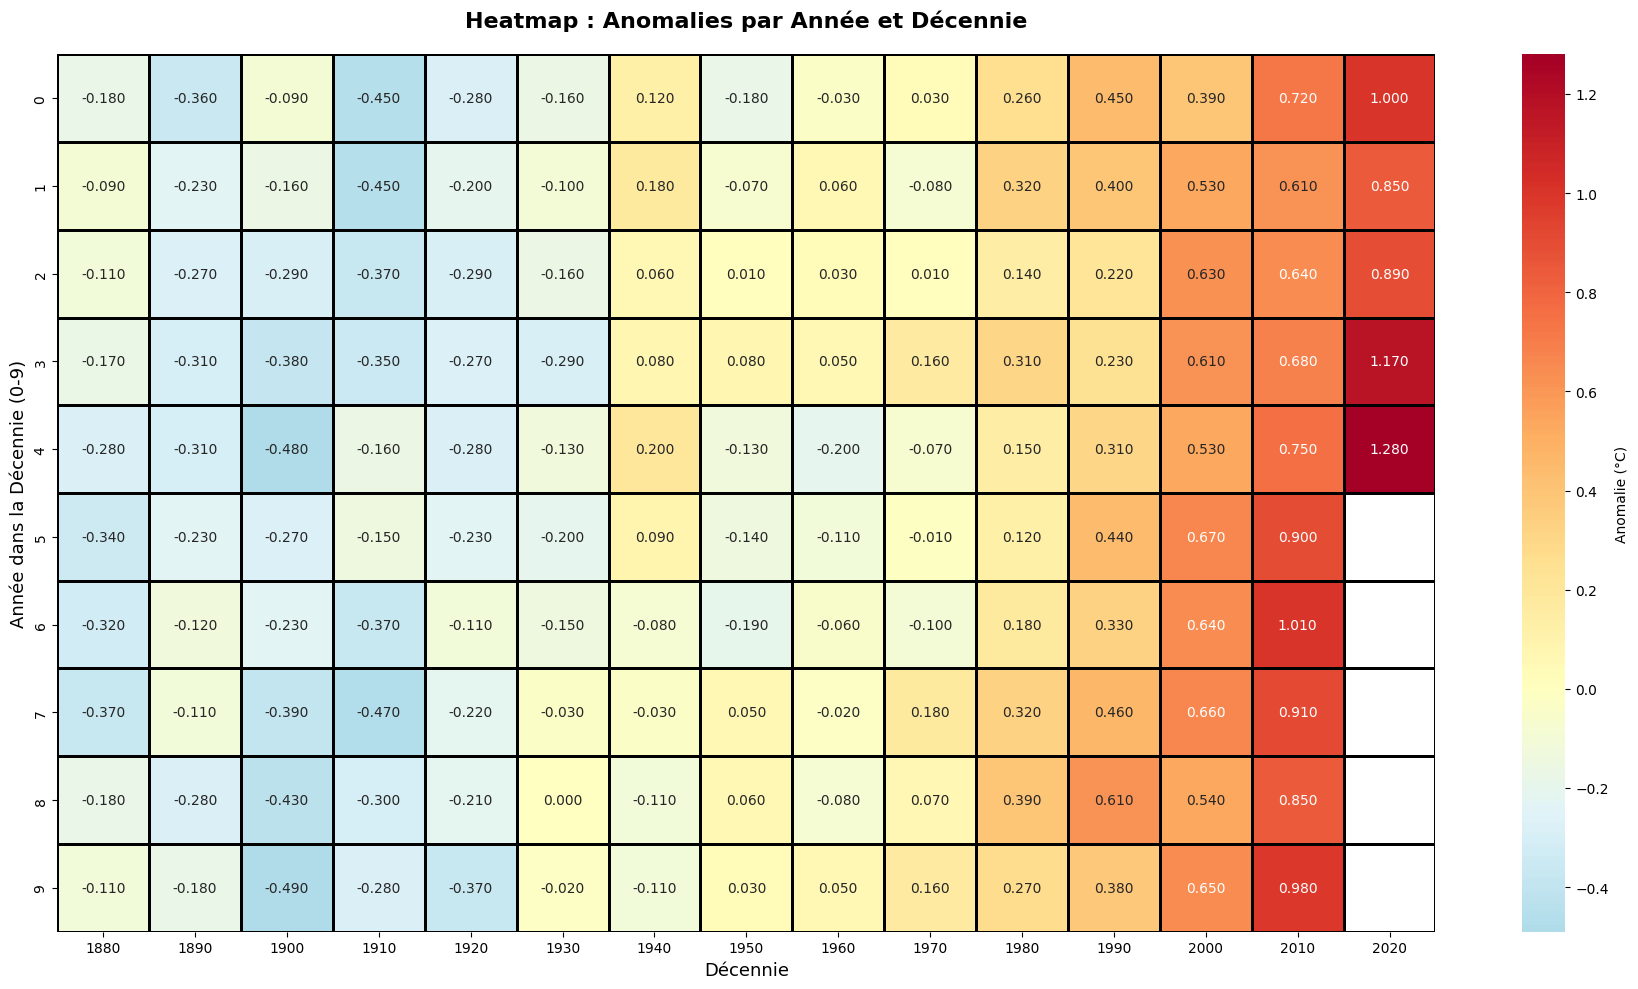

In [20]:
#HEATMAP par année et décennie
fig2, ax = plt.subplots(figsize=(18, 10))

#matrice année x décennie
df['Decade'] = (df['Year'] // 10) * 10
df['YearInDecade'] = df['Year'] % 10

pivot_data = df.pivot_table(values='J-D', index='YearInDecade', columns='Decade', aggfunc='mean')

sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
center=0, linewidths=1, linecolor='black', 
cbar_kws={'label': 'Anomalie (°C)'}, ax=ax)

ax.set_title('Heatmap : Anomalies par Année et Décennie', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Décennie', fontsize=13)
ax.set_ylabel('Année dans la Décennie (0-9)', fontsize=13)

plt.tight_layout()
plt.savefig('heatmap_temperature.png', dpi=300, bbox_inches='tight')
plt.show()



# Création des KPIs

In [21]:
print('Total de la colonne Col1', f"{df_new['Col1'].sum():,}")

NameError: name 'df_new' is not defined

In [ ]:
# Affichage des principaux KPI pour chaque critère
titreKpiGroupByCriteria = 'KPI par critère'
kpiGroupByCriteria = df_new.groupby('ColCriteria').agg({'Col1': 'sum', 'Col2': 'sum', 'Col3': 'sum', 'ColDiff': 'sum', }).reset_index()
print(titreKpiGroupByCriteria)
kpiGroupByCriteria.sort_values(by=['Col1'], ascending=False)

In [ ]:
# Barplot par région sur 2013-2024
kpiGroupByCriteria = kpiGroupByCriteria.sort_values(by=['Col1'], ascending=False)
fig, (ax) = plt.subplots(figsize=(10, 5))

ylabel = 'Col1 value (échelle : 1 = 1 000 TW)'
bar_labels = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'brown', 'pink', 'gray', 'olive', 'green', 'blue']
bar_colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:cyan', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:green', 'tab:blue']

bar_container = ax.bar(kpiGroupByCriteria['ColCriteria'], kpiGroupByCriteria['Col1'])

ax.bar(kpiGroupByCriteria['ColCriteria'], kpiGroupByCriteria['Col1'], label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, fmt='{:,.0f}', rotation='vertical', fontsize=8, label_type='center')
ax.set_ylabel(ylabel)

plt.xticks(rotation=45, ha='right')

In [ ]:
kpiGroupByCriteria['Col2'].sum()

In [ ]:
# Affichage des principaux KPI pour chaque année
kpiGroupByYear = df.groupby('Année').agg({'Col1': 'sum', 'Col1': 'sum', 'ColDiff': 'sum', 'Col2': 'sum'})
kpiGroupByYear.sort_values(by=['Année'], ascending=False)

# Analyse par ColCriteria

In [ ]:
# Affichage des volumes de production par filière pour chaque région
prodGroupByCriteria = df_new.groupby('ColCriteria').agg({'Col1': 'sum', 'Col2': 'sum'}).reset_index()
prodGroupByCriteria.sort_values(by=['Col1'], ascending=False)

In [ ]:
# Création d'un df indiquant les % de chaque critère dans la production pour chaque filière
prodGroupByCriteriaPercentage = prodGroupByCriteria

# Création des colonnes qui indique le ratio 'Filière (MW)' / 'Production (MW)'
prodGroupByCriteriaPercentage['Col99 (%)'] = prodGroupByCriteria['Col1'] / prodGroupByCriteria['Coltotal'].sum()

In [ ]:
prodGroupByCriteriaPercentage.sort_values(by=['Col3'], ascending=False)

# Analyse par Criteria2

In [ ]:
labels = prodGroupByCriteriaPercentage['Criteria']
sizes = prodGroupByCriteriaPercentage['ColCriteria2']

explode = prodGroupByCriteriaPercentage['ColCriteria2'].apply(lambda x:x > 100)
explode = explode.apply(lambda x:0.2 if x == True else 0)
print("Part respective de chaque Criteria dans la ColCriteria2")
plt.title("")
plt.pie(sizes, explode=explode,autopct='%1.2f%%',shadow=True, radius=2)
plt.legend(labels, loc="center")
plt.show()

In [ ]:
import squarify

# Sample data
values = prodGroupByCriteriaPercentage['ColCriteria3']
perc = [str('{:5.2f}'.format(i/prodGroupByCriteriaPercentage['ColCriteria3'].sum()*100)) + "%" for i in prodGroupByCriteriaPercentage['ColCriteria3']]
labels = [f'{crit1}\n{rate}' for crit1, rate in zip(prodGroupByCriteriaPercentage['Criteria'], perc)]

# Treemap
colors = ['#91DCEA', "#C02E29", '#5FBB68', "#DDF508", "#F929D6", "#DDD9D7", "#464FC4", "#08B42D", "#F5D20F", "#2E4E6D", "#E0B470", "#7BF707"]
squarify.plot(sizes = values, label = labels, pad = 0.3, text_kwargs = {'fontsize': 6, 'color': 'black'}, color = colors, alpha = 0.7)

# Remove the axis:
plt.axis("off")

plt.show()

# Analyse par année

## Affichage du lineplot

In [ ]:
# Affichage des volumes de production par filière pour chaque année
prodGroupByYearLine = df_new.groupby('Année').agg({'Col1': 'sum', 'Col2': 'sum'})
prodGroupByYearLine.sort_values(by=['Année'], ascending=True)

In [ ]:
# Création d'un df stacked indiquant les parts (en %) de chaque filière dans la production pour chaque région
prodGroupByYearPercentageLine = prodGroupByYearLine

# Création des colonnes indiquant le ratio 'Filière (MW)' / 'Production (MW)'
prodGroupByYearPercentageLine['Col1'] = prodGroupByYearLine['Col1'] / prodGroupByYearLine['ColTotal']

In [ ]:
sns.lineplot(data=prodGroupByYearPercentageLine)

## Affichage du stackplot

In [ ]:
# Affichage des volumes de production par filière pour chaque année
prodGroupByYearStack = df_new.groupby('Année').agg({'Col1': 'sum', 'Col2': 'sum'}).reset_index()
prodGroupByYearStack.sort_values(by=['Année'], ascending=True)

In [ ]:
# Création d'un df stacked indiquant les parts (en %) de chaque filière dans la production pour chaque région
prodGroupByYearPercentage = prodGroupByYearStack

# Création des colonnes indiquant le ratio 'Filière (MW)' / 'Production (MW)'
prodGroupByYearPercentage['Col1 (%)'] = prodGroupByYearStack['Col1 (vol)'] / prodGroupByYearStack['ColTotal (vol)']

# Suppression des colonnes inutiles

In [ ]:
prodGroupByYearPercentage.sort_values(by=['Année'], ascending=False)

In [ ]:
x = prodGroupByYearPercentage['Année']
y1 = prodGroupByYearPercentage['Col1 (%)']
y2 = prodGroupByYearPercentage['Col2 (%)']
y3 = prodGroupByYearPercentage['Col3 (%)']


plt.bar(x, y1, color='black')
plt.bar(x, y2, bottom=y1, color='yellow')
plt.bar(x, y3, bottom=y1+y2, color='green')
plt.xlabel("Année")
plt.ylabel("% production totale")
plt.legend(["Col1 (%)", "Col2 (%)", "Col3 (%)"])
plt.title("Part de chaque col dans le total")
plt.show()

In [ ]:
prodGroupByYearPercentage.plot(x='Année', kind='bar', stacked=True,
        title='Part de chaque col dans le total')
plt.show()

# Boxplot KPI * Région * Période 10 ans

In [ ]:
# Traçage d'un boxplot à partir des valeurs de la colonne "Consommation (MW)"
titre1 = 'Répartition du KPI par Col1 sur la période ...'
print(titre1)
sns.boxplot(x=kpiGroupByCriteria['Col1'], color=".8")

# Qqplot

In [ ]:
# Boucle qui permet d'afficher les Q-Q plots: 
for column in kpiGroupByCriteria.columns:
    print(column)
    sm.qqplot(kpiGroupByCriteria[column], line='45', fit = True)
